In [1]:
# Import libraries
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

## Read Chla Cube

In [2]:
# Open chla dataset
chla_ds = xr.open_dataset('data/chla_slc_clip_1726_mask02.nc')

# --
chla_ds

<xarray.Dataset> Size: 3GB
Dimensions:      (time: 487, y: 1074, x: 628)
Coordinates:
  * time         (time) datetime64[ns] 4kB 2018-01-03T14:31:14.012000 ... 202...
  * y            (y) float64 9kB 6.534e+06 6.534e+06 ... 6.523e+06 6.523e+06
  * x            (x) float64 5kB 3.575e+05 3.575e+05 ... 3.638e+05 3.638e+05
    spatial_ref  int64 8B ...
Data variables:
    chla         (time, y, x) float64 3GB ...

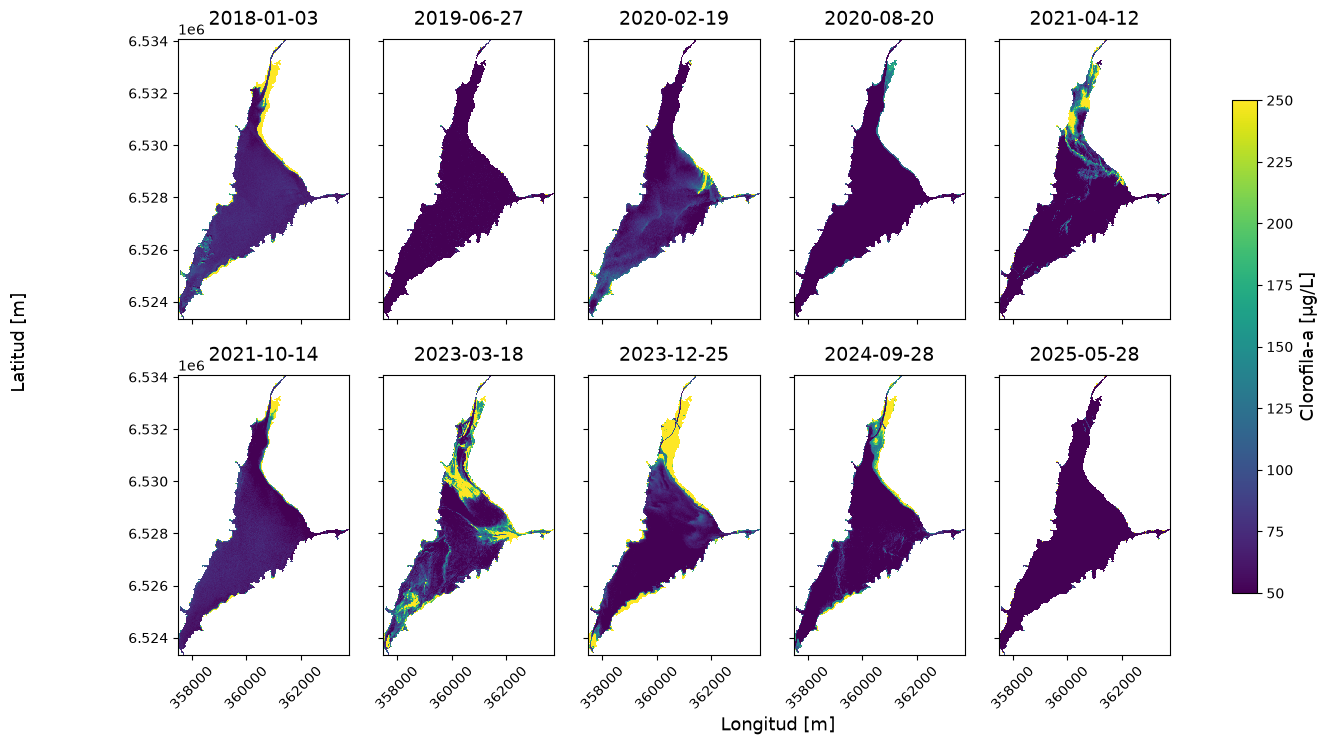

In [3]:
# Plot example
fig, ax = plt.subplots(2, 5, figsize=(16, 8), sharey=True, sharex=True)#, tight_layout=True)
ax=ax.flatten()

for pidx, tidx in enumerate(np.arange(0, len(chla_ds.time.values), len(chla_ds.time.values)//10)[:-1]):
    #print(pidx, tidx )
    data = chla_ds.isel(time=tidx)['chla']
    data_values = data.values
    chla_ds.isel(time=tidx)['chla'].plot(ax=ax[pidx], vmin=50, vmax=250, add_colorbar=False)
    ax[pidx].set_title(f'{str(chla_ds.time.values[tidx])[:10]}', fontsize=14, pad=10)
    ax[pidx].set_ylabel(' ', fontsize=13)
    ax[pidx].set_xlabel(' ', fontsize=13)
    ax[pidx].tick_params(axis='x', labelrotation=45)

# --
# Figure-level axis labels
fig.supxlabel('Longitud [m]', fontsize=13)
fig.supylabel('Latitud [m]', fontsize=13)

# Create one colorbar for the whole figure
sm = plt.cm.ScalarMappable(
    cmap="viridis",
    norm=plt.Normalize(vmin=50, vmax=250)
)

# Add colobar for the plot
cbar = fig.colorbar(
    sm,
    ax=ax,
    shrink=0.8
)

cbar.set_label('Clorofila-a [µg/L]', fontsize=13)

## K-means analysis

In [4]:
# Store chla values in a 3d numpy array
X = chla_ds['chla'].values

# X shape: (time, x, y) = (194, 1074, 628)
T, NX, NY = X.shape

# DATA RESHAPING -> (pixels, time)
X_resh = X.reshape(T, NX * NY).T.astype(np.float32)   # (674472, 194)

# MASK NAN VALUES (drop pixels with any NaN instead of filling with a fake value)
valid = ~np.isnan(X_resh).any(axis=1)
X_valid = X_resh[valid]

# DATA SCALING (each time step scaled across all pixels)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_valid)

# KMEANS
n_clusters = 5
kmeans = KMeans(n_clusters=n_clusters, n_init=10, random_state=0)
labels_valid = kmeans.fit_predict(X_scaled)

# REBUILD THE MAP (NaN where the pixel was invalid)
labels = np.full(NX * NY, np.nan, dtype=np.float32)
labels[valid] = labels_valid
label_map = labels.reshape(NX, NY)

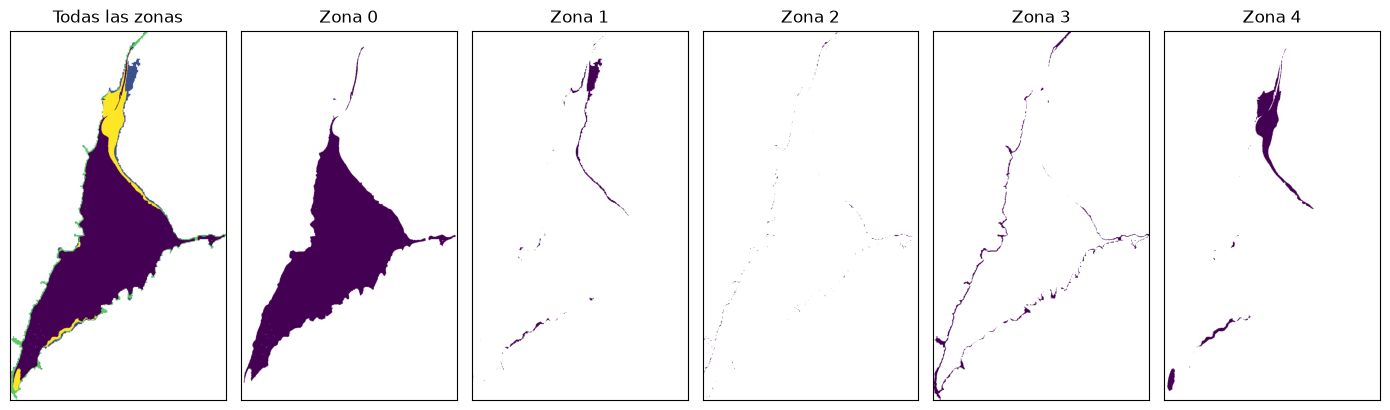

In [6]:
# --
fig, ax = plt.subplots(1, 6,figsize=(14, 6), tight_layout=True)
ax = ax.flatten()

# --
ax[0].imshow(label_map)
ax[0].set_title('Todas las zonas')
ax[0].set_xticks([])
ax[0].set_yticks([])

# --
for idx, l in enumerate(np.unique(labels)[:-1]):
    #print(l)
    ax[idx+1].imshow(np.where(label_map == l, label_map, np.nan))
    ax[idx+1].set_title(f'Zona {int(l)}')
    ax[idx+1].set_xticks([])
    ax[idx+1].set_yticks([])

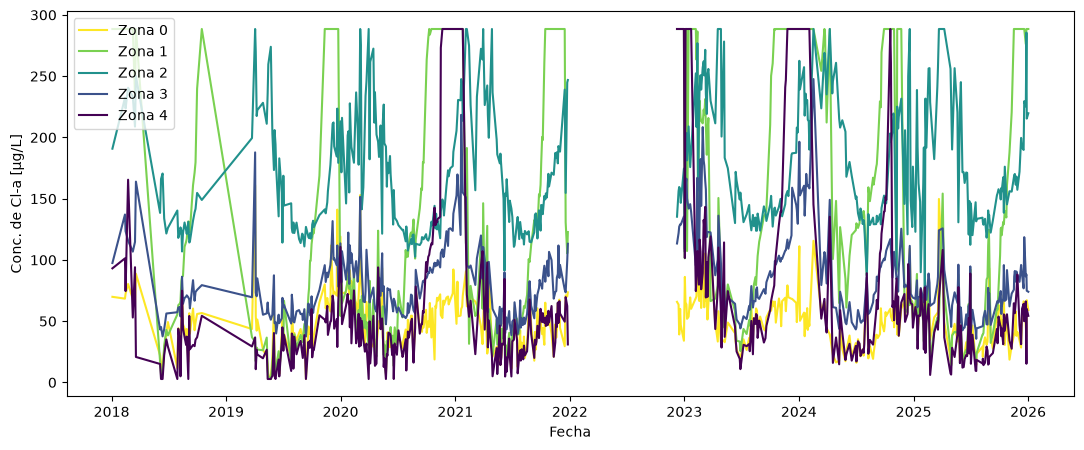

In [32]:
# --
chla_da = chla_ds['chla']

# --
labels_anls = np.unique(label_map)[:-1] #[0, 6, 7, 8, 9]

# --
fig, ax = plt.subplots(figsize=(13, 5))

#--
list_colors = ['#fde725', '#7ad151', '#21918c', '#3b528b', '#440154']

# --
for idx, l in enumerate(labels_anls):
    #print(l)
    data_label = np.where(label_map == l, chla_da, np.nan)
    data_label_mean = np.nanmedian(data_label, axis=(1, 2))
    
    ax.plot(chla_ds.time.values[:259], data_label_mean[:259], color=list_colors[idx], label=f'Zona {int(l)}')
    ax.plot(chla_ds.time.values[260:], data_label_mean[260:], color=list_colors[idx])

# --
ax.set_xlabel('Fecha')
ax.set_ylabel('Conc. de Cl-a [µg/L]')
ax.legend(loc='best', fontsize=10)

In [ ]:
# --
df = pd.DataFrame()

for idx, l in enumerate(labels_anls):
    #print(l)
    data_label = np.where(label_map == l, chla_da, np.nan)
    data_label_mean = np.nanmean(data_label, axis=(1, 2))
    df[f'Lb-{l}'] = data_label_mean

corr = df.corr(method='pearson')   # or 'pearson'
print(corr)

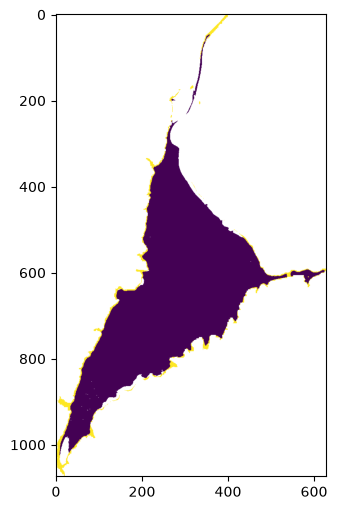

In [16]:
# --
fig, ax = plt.subplots(figsize=(14, 6))

ax.imshow(np.where((label_map == 0) | (label_map == 3), label_map, np.nan))

In [8]:
# --
mask_array = np.where((label_map == 0) | (label_map == 3), 1, np.nan)

# --
mask_da = xr.DataArray(
    mask_array, coords=[chla_da.y.values, chla_da.x.values], dims=['y', 'x']
)


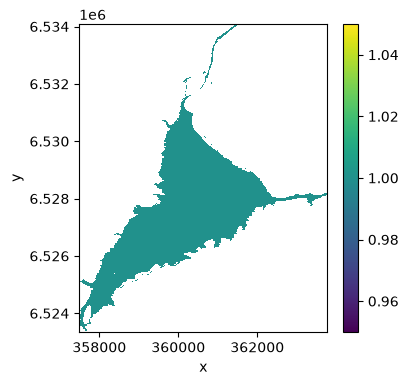

In [9]:
# --
mask_da.plot(figsize=(4, 4))

In [11]:
# --
mask_da.to_netcdf('output/esr_mask.nc')

In [10]:
# --
chla_da_sel = chla_da.sel(time=slice('2019-12-31', '2026-01-01'))
chla_da_mask = xr.where(mask_da==1, chla_da_sel, np.nan)#.time.values
#chla_da_sel = chla_da_mask.sel(time=slice('2022-12-31', '2026-01-01'))

# --
chla_da_medn = chla_da_sel.median(dim=['x', 'y'], skipna=True).values
dates_norm = chla_da_mask.time.values.astype('datetime64[D]')

In [11]:
# --
df_chla_ttss = pd.DataFrame({'yy-mm-dd': dates_norm, 'CHLA_S2-ugL': chla_da_medn})

# --
df_chla_ttss.head(5)

,yy-mm-dd,CHLA_S2-ugL
0,2019-12-31,117.209839
1,2020-01-03,75.399937
2,2020-01-05,72.855106
3,2020-01-18,73.534883
4,2020-01-23,84.153028


In [12]:
# --
df_chla_ttss.to_csv('output/chla_ttss_232604.csv', index=False)